<a href="https://colab.research.google.com/github/Yashika19vats/Trade_Performance_Analysis/blob/main/Trade_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exploring the relationship between trader performance and market
sentiment, uncover hidden patterns, and deliver insights that can drive smarter trading
strategies.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing Datasets

In [3]:
import pandas as pd
trades = pd.read_csv('/content/drive/My Drive/Colab Notebooks/historical_data.csv')
sentiment = pd.read_csv('/content/drive/My Drive/Colab Notebooks/fear_greed_index.csv')

In [60]:
#Performing EDA
trades.head(5)

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,profitable,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,False,2024-02-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,False,2024-02-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,False,2024-02-12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,False,2024-02-12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,False,2024-02-12


In [5]:
sentiment.head(5)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [52]:
trades.info()
trades.describe()
trades.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   account           211224 non-null  object        
 1   coin              211224 non-null  object        
 2   execution_price   211224 non-null  float64       
 3   size_tokens       211224 non-null  float64       
 4   size_usd          211224 non-null  float64       
 5   side              211224 non-null  object        
 6   timestamp_ist     79225 non-null   datetime64[ns]
 7   start_position    211224 non-null  float64       
 8   direction         211224 non-null  object        
 9   closed_pnl        211224 non-null  float64       
 10  transaction_hash  211224 non-null  object        
 11  order_id          211224 non-null  int64         
 12  crossed           211224 non-null  bool          
 13  fee               211224 non-null  float64       
 14  trad

,0
account,0
coin,0
execution_price,0
size_tokens,0
size_usd,0
side,0
timestamp_ist,131999
start_position,0
direction,0
closed_pnl,0


In [16]:
sentiment.info()
sentiment.describe()
sentiment.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


,0
timestamp,0
value,0
classification,0
date,0


In [8]:
#Changing timestamp datatype accordingly
trades['timestamp_IST'] = pd.to_datetime(trades['Timestamp IST'], format="%d-%m-%Y %H:%M")

In [21]:
sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'], unit='s')

In [20]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [29]:
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], errors='coerce')
print(trades['timestamp_ist'].dtypes)

datetime64[ns]


In [30]:
trades['date'] = trades['timestamp_ist'].dt.date

Creating new measure "Profitable"

In [13]:
trades['profitable'] = trades['closed_pnl'] > 0

Merging both datasets on basis of "Date"

In [31]:
merged_df = trades.merge(sentiment[['date', 'classification', 'value']], on='date', how='left')

In [32]:
print(merged_df.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp', 'profitable', 'date', 'classification', 'value'],
      dtype='object')


Performing analysis on merged datasets

In [34]:
#checking average pnl per sentiment
merged_df.groupby('classification')['closed_pnl'].mean()

,closed_pnl
classification,
Extreme Fear,1.891632
Extreme Greed,205.816345
Fear,128.287950
Greed,53.988003
Neutral,27.088803


In [35]:
#percentage of profitability tarade per sentiment
merged_df.groupby('classification')['profitable'].mean()*100

,profitable
classification,
Extreme Fear,29.277730
Extreme Greed,55.328233
Fear,38.178672
Greed,43.570670
Neutral,49.492017


In [36]:
#number of trades per sentiment
merged_df['classification'].value_counts()

,count
classification,
Fear,13869
Greed,11292
Extreme Greed,5621
Neutral,2756
Extreme Fear,2326


In [38]:
#group by sentiments and sides
merged_df.groupby(['classification', 'side'])['closed_pnl'].mean()

classification  side
Extreme Fear    BUY      -3.248825
                SELL      7.076480
Extreme Greed   BUY       9.047055
                SELL    288.350131
Fear            BUY     210.426466
                SELL     36.824047
Greed           BUY      15.661324
                SELL     89.201657
Neutral         BUY      12.484274
                SELL     35.669805
Name: closed_pnl, dtype: float64

In [39]:
#average usd by sentiments
merged_df.groupby('classification')['size_usd'].mean()

,size_usd
classification,
Extreme Fear,4118.761840
Extreme Greed,3242.085086
Fear,5744.782685
Greed,5051.878829
Neutral,4332.202906


In [43]:
#trade count by sentiment
merged_df.groupby(['classification', 'side']).size().unstack()

side,BUY,SELL
classification,,
Extreme Fear,1168,1158
Extreme Greed,1661,3960
Fear,7307,6562
Greed,5407,5885
Neutral,1020,1736


In [42]:
#pnl by side per sentiment
merged_df.groupby(['classification', 'side'])['closed_pnl'].mean().unstack()

side,BUY,SELL
classification,,
Extreme Fear,-3.248825,7.076480
Extreme Greed,9.047055,288.350131
Fear,210.426466,36.824047
Greed,15.661324,89.201657
Neutral,12.484274,35.669805


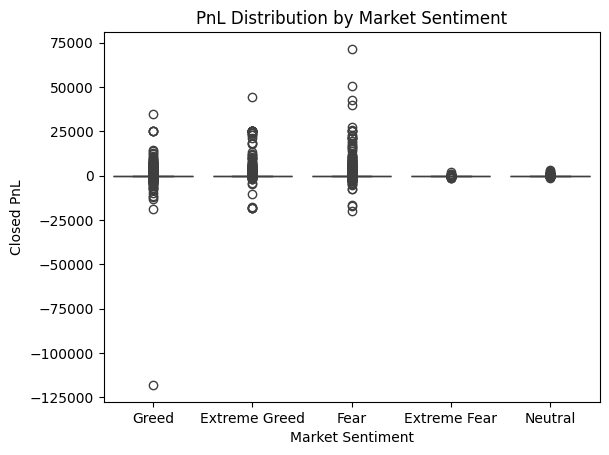

In [37]:
#distribution of pnl per sentiment
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='closed_pnl', data=merged_df)
plt.title("PnL Distribution by Market Sentiment")
plt.ylabel("Closed PnL")
plt.xlabel("Market Sentiment")
plt.show()


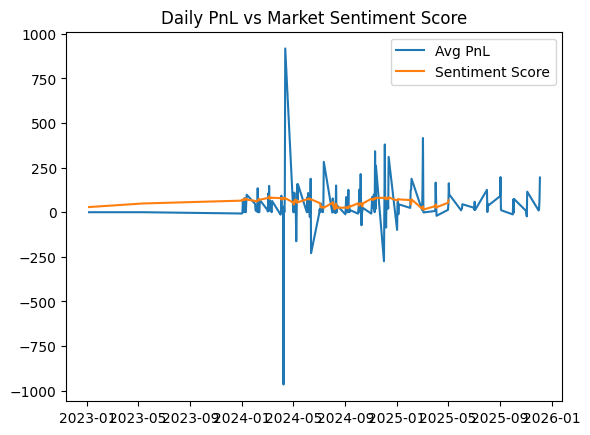

In [44]:
daily_stats = merged_df.groupby('date').agg({
    'closed_pnl': 'mean',
    'value': 'mean'  # sentiment score
}).reset_index()

# Plot
import matplotlib.pyplot as plt
plt.plot(daily_stats['date'], daily_stats['closed_pnl'], label='Avg PnL')
plt.plot(daily_stats['date'], daily_stats['value'], label='Sentiment Score')
plt.legend()
plt.title("Daily PnL vs Market Sentiment Score")
plt.show()


In [48]:
#identifying top performer
trader_perf = merged_df.groupby('account')['closed_pnl'].sum().sort_values(ascending=False)
top_traders = trader_perf.head(10)
bottom_traders = trader_perf.tail(10)
print("Top traders are:",top_traders)
print("Bottom traders are:",bottom_traders)

Top traders are: account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: closed_pnl, dtype: float64
Bottom traders are: account
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     53496.247243
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     47885.320514
0x8477e447846c758f5a675856001ea72298fd9cb5     43917.008976
0xb899e522b5715391ae1d4f137653e7906c5e2115     22488.500821
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb     21758.831753
0x7f4f299f74eec87806a830

In [49]:
#do traders use large size in greed
merged_df.groupby('classification')['size_usd'].mean()

,size_usd
classification,
Extreme Fear,4118.761840
Extreme Greed,3242.085086
Fear,5744.782685
Greed,5051.878829
Neutral,4332.202906


In [51]:
#Correlation score of pnl and sentiments
merged_df[['value', 'closed_pnl']].corr()

,value,closed_pnl
value,1.000,0.011
closed_pnl,0.011,1.000


Using Random Forest Classifier to predict profit

In [57]:
#predicting profit using ML model
# Encoding categorical features
df = merged_df.copy()

df['side'] = df['side'].map({'BUY': 1, 'SELL': 0})
df['classification'] = df['classification'].replace({
    'Extreme Fear': 'Fear',
    'Extreme Greed': 'Greed'
})

df['classification'] = df['classification'].map({'Fear': 0, 'Greed': 1})

#encoding coin using one-hot
df = pd.get_dummies(df, columns=['coin'], drop_first=True)

# Dropping  columns
X = df[['side', 'value', 'size_usd', 'fee', 'start_position'] + [col for col in df.columns if col.startswith('coin_')]]
y = df['profitable'].astype(int)


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9519706474138951
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     24802
           1       0.92      0.97      0.94     17443

    accuracy                           0.95     42245
   macro avg       0.95      0.95      0.95     42245
weighted avg       0.95      0.95      0.95     42245

